<a href="https://colab.research.google.com/github/GayatriVidhate23/Machine--Vision-Practical/blob/main/MV_PRA_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving mv5.jpg to mv5.jpg


In [2]:
import cv2
import matplotlib.pyplot as plt

In [3]:
# Load Haar Cascade XML files
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
                                     'haarcascade_frontalface_default.xml')

eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades +
                                    'haarcascade_eye.xml')

In [5]:
image = cv2.imread("mv5.jpg")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [6]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(50, 50)
)

print("Number of Faces Detected:", len(faces))

Number of Faces Detected: 1


In [7]:
face_count = 0
eye_count = 0

for (x, y, w, h) in faces:

    face_count += 1

    cv2.rectangle(image,
                  (x, y),
                  (x+w, y+h),
                  (255, 0, 0),
                  2)

    roi_gray = gray[y:y+h, x:x+w]
    roi_color = image[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(
        roi_gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    eye_count += len(eyes)

    for (ex, ey, ew, eh) in eyes:

        cv2.rectangle(roi_color,
                      (ex, ey),
                      (ex+ew, ey+eh),
                      (0,255,0),
                      2)

print("Faces Detected:", face_count)
print("Eyes Detected:", eye_count)

Faces Detected: 1
Eyes Detected: 2


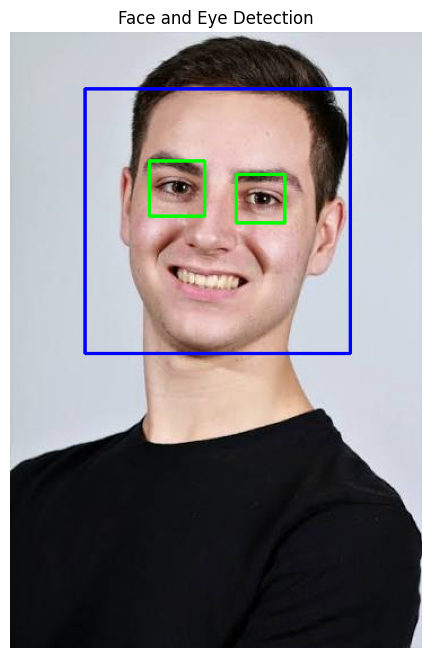

In [8]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Face and Eye Detection")
plt.show()

In [10]:
!pip install opencv-python matplotlib scikit-learn

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import time

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [12]:
from google.colab import files

uploaded = files.upload()

Saving mv5.jpg to mv5 (1).jpg


In [13]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

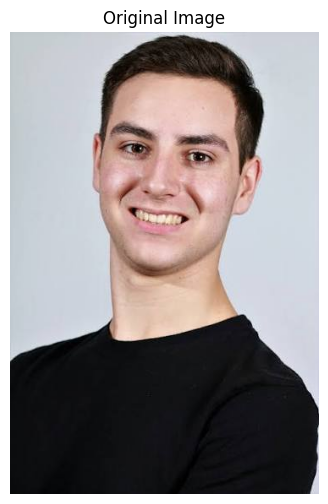

In [18]:
image = cv2.imread("mv5.jpg")

rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

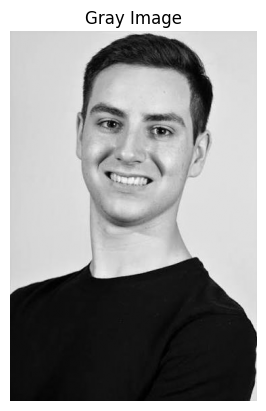

In [19]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray,cmap='gray')
plt.axis("off")
plt.title("Gray Image")
plt.show()

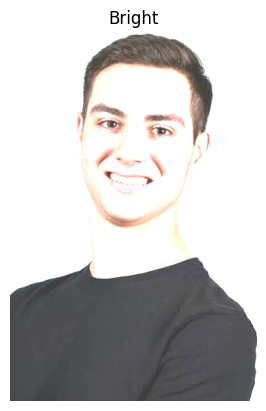

In [20]:
bright = cv2.convertScaleAbs(image,
                             alpha=1.3,
                             beta=60)

plt.imshow(cv2.cvtColor(bright,cv2.COLOR_BGR2RGB))
plt.title("Bright")
plt.axis("off")
plt.show()

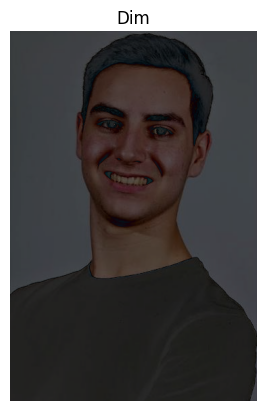

In [21]:
dim = cv2.convertScaleAbs(image,
                          alpha=0.5,
                          beta=-40)

plt.imshow(cv2.cvtColor(dim,cv2.COLOR_BGR2RGB))
plt.title("Dim")
plt.axis("off")
plt.show()

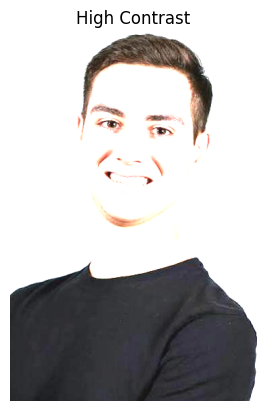

In [22]:
high = cv2.convertScaleAbs(image,
                           alpha=2,
                           beta=20)

plt.imshow(cv2.cvtColor(high,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("High Contrast")
plt.show()

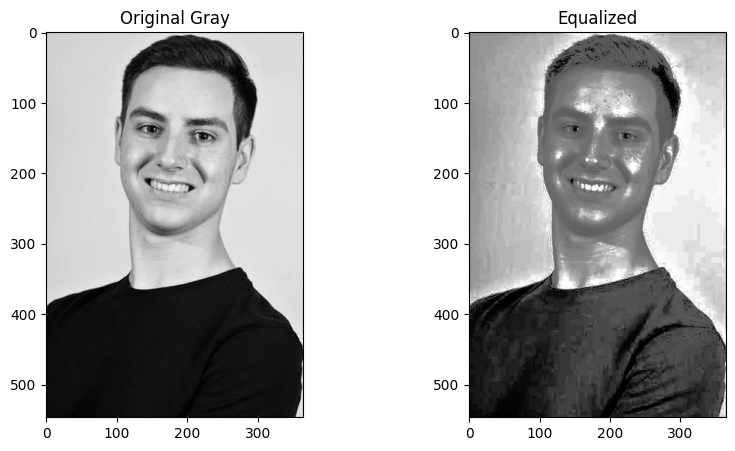

In [23]:
gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

equalized = cv2.equalizeHist(gray)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(gray,cmap='gray')
plt.title("Original Gray")

plt.subplot(122)
plt.imshow(equalized,cmap='gray')
plt.title("Equalized")

plt.show()

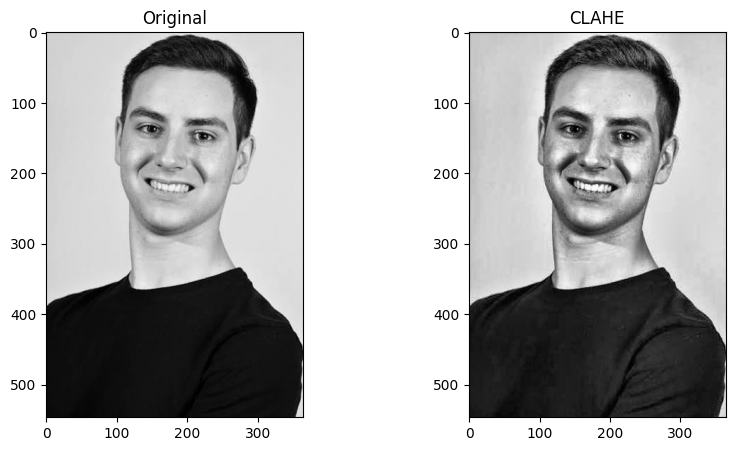

In [24]:
clahe = cv2.createCLAHE(clipLimit=2.0,
                        tileGridSize=(8,8))

clahe_img = clahe.apply(gray)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(gray,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(clahe_img,cmap='gray')
plt.title("CLAHE")

plt.show()